# 2. Regresión Logística — Predicting Electric Vehicle Purchases

Primer modelo del episodio: un **baseline lineal e interpretable** sobre el que medir todo lo que
venga después.

- **Métrica oficial:** ROC AUC. Se evalúa con `StratifiedKFold(5)` sobre `train`.
- **Nulos:** no hay ninguno (lo confirmó `1_eda.ipynb`), pero el `SimpleImputer` queda en el pipeline
  igual: no cuesta nada y protege si aparecieran en test.
- **Escalado:** obligatorio en un modelo lineal regularizado; además vuelve comparables los
  coeficientes entre sí.

El EDA dejó tres hipótesis para poner a prueba acá:

1. `log(Annual_Income_USD)` debería ayudar, porque la curva de log-odds es más empinada en los
   deciles bajos.
2. El cruce `City_Type` × `Home_Charging_Possible` es una interacción genuina y un logit aditivo no
   puede representarla.
3. Los cruces de `Subsidy_Available` con `Range_Anxiety_Level` y con `Environmental_Concern_Level`
   **no** deberían aportar, porque son aditivos en log-odds.

**Dataset:** Playground Series S6E9

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["figure.dpi"] = 100

SEED = 42

## 1. Carga y Preprocesamiento

In [2]:
train_raw = pd.read_csv("../data/train.csv")
test_raw  = pd.read_csv("../data/test.csv")

TARGET = "Will_Buy_EV"

crudas_num = ["Age", "Annual_Income_USD", "Daily_Commute_km", "Number_of_Cars_Owned",
              "Charging_Stations_Near_Home", "Charging_Stations_Near_Work",
              "Environmental_Concern_Level"]
crudas_cat = ["Gender", "City_Type", "Current_Car_Type",
              "Home_Charging_Possible", "Subsidy_Available", "Range_Anxiety_Level"]


def agregar_derivadas(df):
    """Replica las features derivadas motivadas en 1_eda.ipynb."""
    d = df.copy()
    # El log-odds del target sube mas rapido en los ingresos bajos: el log comprime esa cola.
    d["log_income"]      = np.log(d["Annual_Income_USD"])
    d["income_per_car"]  = d["Annual_Income_USD"] / d["Number_of_Cars_Owned"]
    d["charging_total"]  = d["Charging_Stations_Near_Home"] + d["Charging_Stations_Near_Work"]
    # Ordinal tratado como categorica, por si la relacion no es del todo lineal en log-odds.
    d["env_concern_cat"] = d["Environmental_Concern_Level"].astype(str)
    # Interacciones como categoricas concatenadas (todas de cardinalidad chica).
    d["home_x_city"]     = d["Home_Charging_Possible"] + "_" + d["City_Type"]
    d["subsidy_x_anx"]   = d["Subsidy_Available"] + "_" + d["Range_Anxiety_Level"]
    d["subsidy_x_env"]   = d["Subsidy_Available"] + "_" + d["env_concern_cat"]
    return d.replace([np.inf, -np.inf], np.nan)


derivadas_num = ["log_income", "income_per_car", "charging_total"]
derivadas_cat = ["env_concern_cat", "home_x_city"]
cruces_extra  = ["subsidy_x_anx", "subsidy_x_env"]

train = agregar_derivadas(train_raw)
test  = agregar_derivadas(test_raw)
y     = (train[TARGET] == "Yes").astype(int)

print(f"Train: {train_raw.shape[0]:,} filas x {train_raw.shape[1]} columnas")
print(f"Test:  {test_raw.shape[0]:,} filas x {test_raw.shape[1]} columnas")
print(f"Tasa base: {y.mean():.4%}")
print(f"\nDerivadas numericas  ({len(derivadas_num)}): {derivadas_num}")
print(f"Derivadas categoricas ({len(derivadas_cat)}): {derivadas_cat}")
print(f"Cruces extra          ({len(cruces_extra)}): {cruces_extra}")

Train: 668,665 filas x 15 columnas
Test:  286,571 filas x 14 columnas
Tasa base: 17.4645%

Derivadas numericas  (3): ['log_income', 'income_per_car', 'charging_total']
Derivadas categoricas (2): ['env_concern_cat', 'home_x_city']
Cruces extra          (2): ['subsidy_x_anx', 'subsidy_x_env']


## 2. Pipeline de Preprocesamiento

La regresión logística no acepta categóricas en texto y es sensible a la escala. El `Pipeline`
resuelve las dos cosas y —al ir **dentro** de la validación cruzada— garantiza que las medias de
escalado y los niveles del one-hot se calculen sólo con el fold de entrenamiento, sin leakage hacia
el fold de validación.

Se comparan cuatro conjuntos de features para aislar cuánto aporta cada bloque. La configuración D
existe para contrastar la hipótesis 3 del EDA: si los cruces de `Subsidy_Available` son realmente
aditivos, D no debería mejorar a C.

In [3]:
def construir_pipeline(num_cols, cat_cols, C=1.0):
    bloques = [("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                                 ("esc", StandardScaler())]), num_cols)]
    if cat_cols:
        bloques.append(("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                                         ("ohe", OneHotEncoder(handle_unknown="ignore",
                                                               drop="first"))]), cat_cols))
    return Pipeline([("pre", ColumnTransformer(bloques)),
                     ("clf", LogisticRegression(C=C, max_iter=1000, random_state=SEED))])


configs = {
    "A. solo Environmental_Concern": (["Environmental_Concern_Level"], []),
    "B. crudas":                     (crudas_num, crudas_cat),
    "C. crudas + derivadas":         (crudas_num + derivadas_num, crudas_cat + derivadas_cat),
    "D. C + cruces de subsidio":     (crudas_num + derivadas_num,
                                      crudas_cat + derivadas_cat + cruces_extra),
}

for nombre, (n, c) in configs.items():
    print(f"{nombre:32s} -> {len(n)} numericas + {len(c)} categoricas")

A. solo Environmental_Concern    -> 1 numericas + 0 categoricas
B. crudas                        -> 7 numericas + 6 categoricas
C. crudas + derivadas            -> 10 numericas + 8 categoricas
D. C + cruces de subsidio        -> 10 numericas + 10 categoricas


## 3. Validación Cross-Validation (ROC AUC)

`StratifiedKFold(5)` con shuffle. La configuración A funciona como piso de referencia: es la variable
más fuerte del EDA usada sola (AUC univariado 0,8435).

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

resultados = {}
print(f"{'='*66}")
print("CROSS-VALIDATION 5-FOLD — ROC AUC")
print(f"{'='*66}")
for nombre, (num_cols, cat_cols) in configs.items():
    scores = cross_val_score(construir_pipeline(num_cols, cat_cols),
                             train[num_cols + cat_cols], y, cv=skf,
                             scoring="roc_auc", n_jobs=4)
    resultados[nombre] = scores
    print(f"  {nombre:32s} AUC = {scores.mean():.5f} +/- {scores.std():.5f}")
print(f"{'='*66}")

MEJOR   = max(resultados, key=lambda k: resultados[k].mean())
cv_mean = resultados[MEJOR].mean()
print(f"  Mejor configuracion: {MEJOR}")
print(f"  CV AUC:              {cv_mean:.5f}")

CROSS-VALIDATION 5-FOLD — ROC AUC


  A. solo Environmental_Concern    AUC = 0.84352 +/- 0.00135


  B. crudas                        AUC = 0.93810 +/- 0.00080


  C. crudas + derivadas            AUC = 0.93855 +/- 0.00083


  D. C + cruces de subsidio        AUC = 0.93852 +/- 0.00082
  Mejor configuracion: C. crudas + derivadas
  CV AUC:              0.93855


In [5]:
# Cuanto aporta cada bloque respecto del anterior
base = None
print("Aporte incremental:")
for nombre in configs:
    m = resultados[nombre].mean()
    delta = "" if base is None else f"   ({m - base:+.5f} vs anterior)"
    print(f"  {nombre:32s} {m:.5f}{delta}")
    base = m

Aporte incremental:
  A. solo Environmental_Concern    0.84352
  B. crudas                        0.93810   (+0.09457 vs anterior)
  C. crudas + derivadas            0.93855   (+0.00045 vs anterior)
  D. C + cruces de subsidio        0.93852   (-0.00003 vs anterior)


## 4. Diagnóstico — Curva ROC y Separación de Probabilidades

AUC out-of-fold: 0.93855   (media de CV: 0.93855)


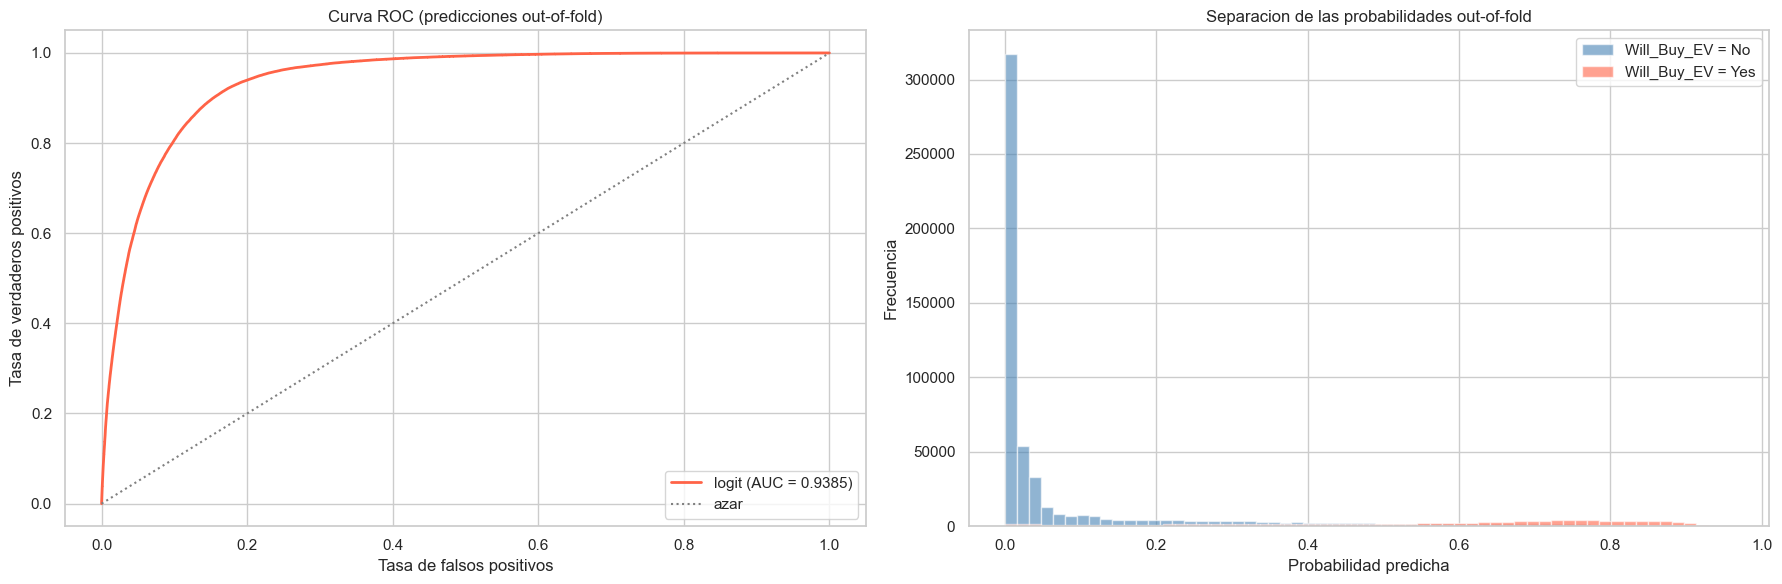

In [6]:
num_cols, cat_cols = configs[MEJOR]
features = num_cols + cat_cols

oof = cross_val_predict(construir_pipeline(num_cols, cat_cols), train[features], y,
                        cv=skf, method="predict_proba", n_jobs=4)[:, 1]
auc_oof = roc_auc_score(y, oof)
print(f"AUC out-of-fold: {auc_oof:.5f}   (media de CV: {cv_mean:.5f})")

fpr, tpr, _ = roc_curve(y, oof)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].plot(fpr, tpr, color="tomato", lw=2, label=f"logit (AUC = {auc_oof:.4f})")
axes[0].plot([0, 1], [0, 1], color="gray", ls=":", lw=1.5, label="azar")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_title("Curva ROC (predicciones out-of-fold)")
axes[0].legend(loc="lower right")
for cls, color, etiqueta in [(0, "steelblue", "No"), (1, "tomato", "Yes")]:
    axes[1].hist(oof[y == cls], bins=60, alpha=0.6, color=color,
                 label=f"Will_Buy_EV = {etiqueta}")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Separacion de las probabilidades out-of-fold")
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Modelo Final — Entrenamiento sobre todo el Train

In [7]:
modelo_final = construir_pipeline(num_cols, cat_cols)
modelo_final.fit(train[features], y)
print(f"Modelo final entrenado sobre {len(train):,} filas y {len(features)} features de entrada.")

Modelo final entrenado sobre 668,665 filas y 18 features de entrada.


## 6. Coeficientes del Modelo

Con las numéricas estandarizadas los coeficientes son comparables entre sí: cada uno es el cambio en
el log-odds ante **un desvío estándar** de la variable. Es la ventaja del logit frente a un modelo de
árboles.

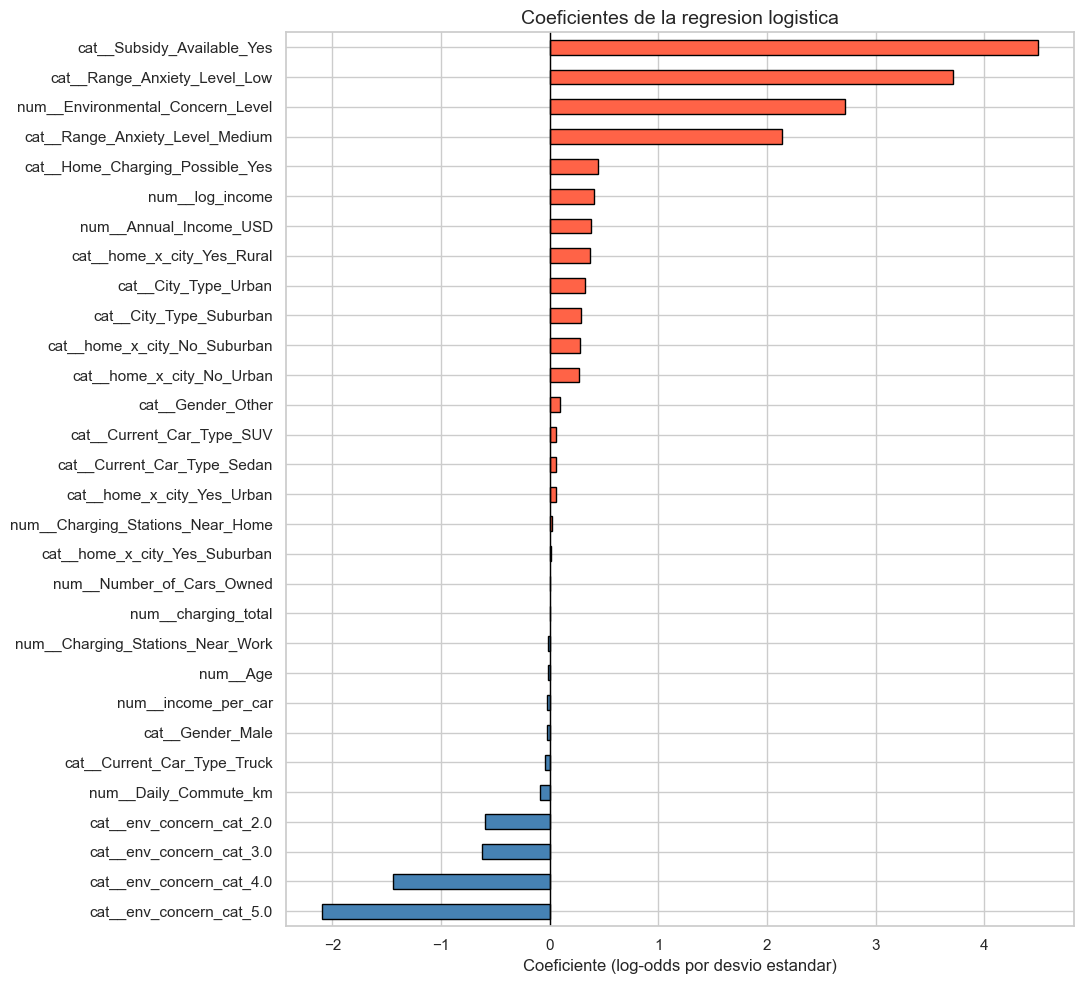

Top 12 por magnitud:
cat__Subsidy_Available_Yes          4.4942
cat__Range_Anxiety_Level_Low        3.7133
num__Environmental_Concern_Level    2.7209
cat__Range_Anxiety_Level_Medium     2.1388
cat__env_concern_cat_5.0           -2.0964
cat__env_concern_cat_4.0           -1.4397
cat__env_concern_cat_3.0           -0.6218
cat__env_concern_cat_2.0           -0.5957
cat__Home_Charging_Possible_Yes     0.4467
num__log_income                     0.4072
num__Annual_Income_USD              0.3769
cat__home_x_city_Yes_Rural          0.3739


In [8]:
nombres = modelo_final.named_steps["pre"].get_feature_names_out()
coefs   = pd.Series(modelo_final.named_steps["clf"].coef_[0], index=nombres).sort_values()

fig, ax = plt.subplots(figsize=(11, 10))
coefs.plot.barh(ax=ax, color=["steelblue" if v < 0 else "tomato" for v in coefs],
                edgecolor="black")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Coeficiente (log-odds por desvio estandar)")
ax.set_title("Coeficientes de la regresion logistica", fontsize=14)
plt.tight_layout()
plt.show()

print("Top 12 por magnitud:")
print(coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12).round(4).to_string())

## 7. Predicción sobre Test y Submission

In [9]:
proba_test = modelo_final.predict_proba(test[features])[:, 1]

# Se guardan OOF y test para poder stackear este modelo mas adelante
np.save("../models/2_logit_oof.npy", oof)
np.save("../models/2_logit_test.npy", proba_test)

submission = pd.DataFrame({"id": test["id"], TARGET: proba_test})
submission.to_csv("../submissions/2_logit_submission.csv", index=False)

print(f"Submission escrita: ../submissions/2_logit_submission.csv ({len(submission):,} filas)")
print(submission.head().to_string(index=False))
print(f"\nProbabilidad media predicha: {proba_test.mean():.4f}"
      f"  (tasa base en train: {y.mean():.4f})")

Submission escrita: ../submissions/2_logit_submission.csv (286,571 filas)
    id  Will_Buy_EV
668665     0.005383
668666     0.027929
668667     0.006243
668668     0.002692
668669     0.016051

Probabilidad media predicha: 0.1748  (tasa base en train: 0.1746)


In [10]:
# Chequeo de sanidad contra sample_submission (formato e ids)
sample = pd.read_csv("../data/sample_submission.csv")
assert list(submission.columns) == list(sample.columns), "columnas no coinciden"
assert len(submission) == len(sample), "cantidad de filas no coincide"
assert (submission["id"].values == sample["id"].values).all(), "los ids no estan alineados"
assert submission[TARGET].between(0, 1).all(), "hay probabilidades fuera de [0, 1]"
assert submission[TARGET].notna().all(), "hay nulos en la prediccion"
print("Chequeos OK — submission lista para enviar.")

Chequeos OK — submission lista para enviar.


## 8. Envío a Kaggle vía API

En este equipo Avast intercepta TLS e inyecta su propia root CA, que no está en el bundle de
`certifi` — sin el fix de abajo la CLI falla con `CERTIFICATE_VERIFY_FAILED` contra `api.kaggle.com`.
La celda regenera el bundle combinando `certifi` con el almacén de certificados de Windows (que sí
confía en esa root). Es la misma solución que en
`Episode 6 - Predicting Stellar Class/notebook/3_catboost.ipynb`.

In [11]:
import sys, os, ssl, subprocess
!{sys.executable} -m pip install --upgrade kaggle --quiet

# --- Fix SSL CERTIFICATE_VERIFY_FAILED en api.kaggle.com ---
import certifi
bundle_path = os.path.join(os.path.dirname(certifi.where()), "win_ca_bundle.pem")
with open(bundle_path, "w", encoding="utf-8") as out:
    out.write(open(certifi.where(), encoding="utf-8").read())
    ps = (
        "$s=@('Cert:\\LocalMachine\\Root','Cert:\\CurrentUser\\Root',"
        "'Cert:\\LocalMachine\\CA','Cert:\\CurrentUser\\CA');"
        "foreach($p in $s){try{Get-ChildItem $p -EA Stop|%{"
        "'-----BEGIN CERTIFICATE-----';"
        "[Convert]::ToBase64String($_.RawData,'InsertLineBreaks');"
        "'-----END CERTIFICATE-----'}}catch{}}"
    )
    win = subprocess.run(["powershell", "-NoProfile", "-Command", ps],
                         capture_output=True, text=True)
    out.write("\n" + win.stdout)

for var in ("REQUESTS_CA_BUNDLE", "SSL_CERT_FILE", "CURL_CA_BUNDLE"):
    os.environ[var] = bundle_path
print("CA bundle listo:", bundle_path)


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: C:\Users\HP\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


CA bundle listo: C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\certifi\win_ca_bundle.pem


In [12]:
COMPETITION = "playground-series-s6e9"
FILE        = "../submissions/2_logit_submission.csv"
MSG         = f"Logit - {MEJOR} - CV AUC={cv_mean:.5f}"

!kaggle competitions submit -c {COMPETITION} -f "{FILE}" -m "{MSG}"

8 submissions remaining today.
Successfully submitted to Predicting Electric Vehicle Purchases



  0%|          | 0.00/7.81M [00:00<?, ?B/s]
  0%|          | 16.0k/7.81M [00:03<30:32, 4.46kB/s]
  2%|▏         | 192k/7.81M [00:03<01:51, 71.7kB/s] 
  6%|▌         | 496k/7.81M [00:04<00:38, 197kB/s] 
  7%|▋         | 592k/7.81M [00:04<00:33, 229kB/s]
  9%|▊         | 688k/7.81M [00:04<00:27, 273kB/s]
 26%|██▌       | 2.00M/7.81M [00:04<00:04, 1.49MB/s]
 71%|███████   | 5.53M/7.81M [00:04<00:00, 5.51MB/s]
100%|██████████| 7.81M/7.81M [00:05<00:00, 1.49MB/s]


In [13]:
# Score publico del envio (esperar unos segundos a que Kaggle lo puntue)
!kaggle competitions submissions -c playground-series-s6e9

     ref  fileName                date                        description                                     status                     publicScore  privateScore  
--------  ----------------------  --------------------------  ----------------------------------------------  -------------------------  -----------  ------------  
55949487  2_logit_submission.csv  2026-09-01 23:29:18.247000  Logit - C. crudas + derivadas - CV AUC=0.93855  SubmissionStatus.PENDING                              
55949486  2_logit_submission.csv  2026-09-01 23:28:58.917000  Logit - C. crudas + derivadas - CV AUC=0.93855  SubmissionStatus.COMPLETE  0.93789                    


## 9. Conclusiones

- **CV AUC = 0,93855** con `crudas + derivadas` (5-fold estratificado, desvío 0,00083 entre folds). El
  AUC out-of-fold da 0,93855, idéntico a la media de CV, así que la estimación es estable.
- **El salto grande es pasar de una variable a todas**: de 0,84352 (`Environmental_Concern_Level`
  sola) a 0,93810 con las 13 crudas, **+0,0946**. Es donde está casi toda la ganancia del modelo.
- **Las derivadas aportan poco**: +0,00045 sobre las crudas (0,93810 → 0,93855). Es un aporte real
  pero de un orden de magnitud comparable al desvío entre folds (0,0008), así que conviene tomarlo
  con pinzas.
- **Las tres hipótesis del EDA, contrastadas:**
  1. `log(Annual_Income_USD)` **entra al modelo** con coeficiente 0,4072, conviviendo con el ingreso
     crudo (0,3769) — entre las dos reparten el efecto y capturan la curvatura. Pero el aporte
     conjunto de todas las derivadas es de apenas +0,00045.
  2. El cruce `City_Type` × `Home_Charging_Possible` **es una interacción genuina pero irrelevante
     para el AUC**. El modelo le asigna coeficiente (0,3739 para `Yes_Rural`), y aun así no mueve la
     aguja: la interacción es real en log-odds, pero involucra dos variables débiles (AUC univariado
     0,55 y 0,52), así que corrige probabilidades en una región donde el ordenamiento global casi no
     cambia. **Interacción estadísticamente real ≠ ganancia en la métrica.**
  3. **Confirmada**: agregar los cruces de `Subsidy_Available` (config D) da **−0,00003**, es decir
     nada. El EDA había anticipado bien que eran aditivos en log-odds, y se evitó gastar features en
     algo que no iba a rendir.
- **Los coeficientes son legibles** (las numéricas no tienen colinealidad entre sí):
  `Subsidy_Available = Yes` vale **+4,49** de log-odds, `Range_Anxiety_Level = Low` **+3,71** y
  `Environmental_Concern_Level` **+2,72** por desvío estándar. Son exactamente las tres variables que
  el EDA había marcado como dominantes.
- **El modelo recupera la forma empírica de `Environmental_Concern_Level`.** Los coeficientes
  negativos de `env_concern_cat` no contradicen al término lineal positivo: conviven porque la
  variable entra dos veces (como numérica y como one-hot), y la combinación de ambos reproduce los
  saltos observados casi exactamente — modelo **1,31 / 1,88 / 1,09 / 1,25** vs empírico
  **1,35 / 1,74 / 0,98 / 1,18**. Es la razón por la que la config C no gana más: la relación ya era
  casi lineal y no quedaba curvatura por explotar.
- **Submission sin señales de shift**: la probabilidad media predicha sobre test es 0,1748, contra una
  tasa base de 0,1746 en train.
- **Score público en Kaggle: 0,93789**, contra un CV de 0,93855. El leaderboard queda 0,00066 **por
  debajo** de la CV — una diferencia menor al desvío entre folds, así que la validación cruzada es un
  proxy fiable, apenas optimista, para decidir entre modelos sin gastar envíos.
- **Distancia al tope**: el primer puesto del leaderboard está en 0,94631, a **+0,0084** de este
  baseline. Es un margen chico en términos absolutos, pero en esta zona de la curva cada milésima
  cuesta.
- **Próximo paso**: gradient boosting (XGBoost / LightGBM). Que las features construidas a mano hayan
  rendido tan poco sugiere que lo que falta no son transformaciones evidentes sino **interacciones de
  orden mayor** entre las variables fuertes — justo lo que un ensamble de árboles encuentra solo.
